In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
path = r"C:\Users\R Y Z E N\Desktop\MachineLearningCSV\MachineLearningCVE"
files = [os.path.join(path, f) for f in os.listdir(path) if f.endswith(".csv")]


In [4]:
df_list = []
for file in files:
    print(f"Loading: {file}")
    chunk_iter = pd.read_csv(file, chunksize=20000, low_memory=False)
    for chunk in chunk_iter:
        # keeping only required sample to avoid memory crash
        chunk = chunk.sample(frac=0.2, random_state=42)
        df_list.append(chunk)
df = pd.concat(df_list, ignore_index=True)
print("Full dataset shape:", df.shape)

Loading: C:\Users\R Y Z E N\Desktop\MachineLearningCSV\MachineLearningCVE\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: C:\Users\R Y Z E N\Desktop\MachineLearningCSV\MachineLearningCVE\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: C:\Users\R Y Z E N\Desktop\MachineLearningCSV\MachineLearningCVE\Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: C:\Users\R Y Z E N\Desktop\MachineLearningCSV\MachineLearningCVE\Monday-WorkingHours.pcap_ISCX.csv
Loading: C:\Users\R Y Z E N\Desktop\MachineLearningCSV\MachineLearningCVE\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: C:\Users\R Y Z E N\Desktop\MachineLearningCSV\MachineLearningCVE\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: C:\Users\R Y Z E N\Desktop\MachineLearningCSV\MachineLearningCVE\Tuesday-WorkingHours.pcap_ISCX.csv
Loading: C:\Users\R Y Z E N\Desktop\MachineLearningCSV\MachineLearningCVE\Wednesday-workingHours.pcap_ISCX.csv
Full dataset shape: (566149, 79)


In [5]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,23613,1,1,59,124,59,59,59.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,23945,2,2,176,340,88,88,88.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,53,48616,4,2,140,168,35,35,35.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,51511,2,2,64,120,32,32,32.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,53,23922,2,2,80,250,40,40,40.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
566144,53,139636,4,2,116,258,29,29,29.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
566145,53,47676,2,2,116,310,58,58,58.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
566146,53,24088,2,2,64,198,32,32,32.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
566147,34988,68,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
566148,443,29131,1,1,0,0,0,0,0.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [8]:
df = df.dropna()
df = df.drop_duplicates()



In [11]:
label_col = None
for col in df.columns:
    if col.lower().strip() == "label":
        label_col = col
        break

if label_col is None:
    raise Exception("Label column not found! Check dataset columns.")

print("Using label column:", label_col)


Using label column:  Label


In [12]:
df[label_col] = df[label_col].apply(lambda x: 0 if str(x).strip() == "BENIGN" else 1)


In [13]:
benign = df[df[label_col] == 0]
attack = df[df[label_col] == 1]

sample_size = min(len(benign), len(attack), 80000)

df_balanced = pd.concat([
    benign.sample(sample_size, random_state=42),
    attack.sample(sample_size, random_state=42)
])

df_balanced = df_balanced.sample(frac=1, random_state=42)

print("Balanced dataset shape:", df_balanced.shape)

Balanced dataset shape: (160000, 79)


In [14]:
X = df_balanced.drop(columns=[label_col])
y = df_balanced[label_col]


In [15]:
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Fix infinity / missing values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y,test_size=0.2,random_state=42,stratify=y
)

In [18]:
model = RandomForestClassifier(n_estimators=200,n_jobs=-1,random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [19]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [21]:
results = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-score"],"Score": [accuracy, precision, recall, f1]})

print("\n===== MODEL PERFORMANCE =====")
print(results)


===== MODEL PERFORMANCE =====
      Metric     Score
0   Accuracy  0.998344
1  Precision  0.998811
2     Recall  0.997875
3   F1-score  0.998343


In [22]:
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16000
           1       1.00      1.00      1.00     16000

    accuracy                           1.00     32000
   macro avg       1.00      1.00      1.00     32000
weighted avg       1.00      1.00      1.00     32000



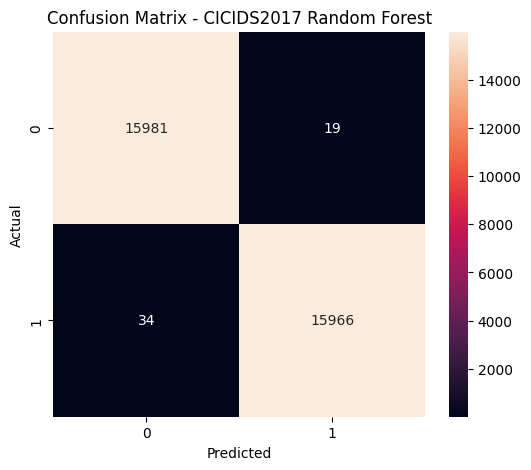

In [23]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - CICIDS2017 Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [24]:
# 16. SAVE MODEL (PKL FILE)

import joblib
model_filename = "random_forest_cicids2017.pkl"
scaler_filename = "scaler_cicids2017.pkl"

# Save trained model
joblib.dump(model, model_filename)

# Save scaler (IMPORTANT for future predictions)
joblib.dump(scaler, scaler_filename)

print("Model saved successfully as:", model_filename)
print("Scaler saved successfully as:", scaler_filename)

Model saved successfully as: random_forest_cicids2017.pkl
Scaler saved successfully as: scaler_cicids2017.pkl
